# Assignment-6: Decision Tree (ID3 Algorithm)

**Objective:** Build a decision tree using the ID3 algorithm, classify new samples, and interpret results. 

---

## Q1: Import Required Libraries

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported')

Libraries imported


### (Helper) Create sample dataset (Play Tennis)

In [34]:
data = {
    'Age':['Young','Young','Middle','Old','Old','Old','Middle','Young','Young','Old','Young','Middle','Middle','Old',
           'Young','Middle','Old','Young','Middle','Old','Young','Middle','Old','Young','Middle','Old','Young','Old'],

    'Income':['High','High','High','Medium','Low','Low','Low','Medium','Low','Medium','Medium','Medium','High','Medium',
              'Low','Medium','High','Medium','Low','Medium','High','Low','Medium','High','Medium','Low','Medium','High'],

    'Student':['No','No','No','No','Yes','Yes','Yes','No','Yes','Yes','Yes','No','Yes','No',
               'Yes','No','Yes','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes'],

    'Credit_Rating':['Fair','Excellent','Fair','Fair','Fair','Excellent','Excellent','Fair','Fair','Fair','Excellent','Excellent','Fair','Excellent',
                     'Fair','Excellent','Fair','Excellent','Fair','Excellent','Fair','Excellent','Fair','Excellent','Fair','Excellent','Fair','Excellent'],

    'Loan_Approved':['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No',
                     'Yes','Yes','Yes','Yes','No','Yes','No','Yes','No','Yes','Yes','Yes','No','Yes']
}
df = pd.DataFrame(data)
df.to_csv('loan.csv', index=False)
df

,Age,Income,Student,Credit_Rating,Loan_Approved
0,Young,High,No,Fair,No
1,Young,High,No,Excellent,No
2,Middle,High,No,Fair,Yes
3,Old,Medium,No,Fair,Yes
4,Old,Low,Yes,Fair,Yes
5,Old,Low,Yes,Excellent,No
6,Middle,Low,Yes,Excellent,Yes
7,Young,Medium,No,Fair,No
8,Young,Low,Yes,Fair,Yes
9,Old,Medium,Yes,Fair,Yes


## Q2: Load Dataset and View First 10 Rows

In [35]:
dataset = pd.read_csv('loan.csv')
dataset.head(10)

,Age,Income,Student,Credit_Rating,Loan_Approved
0,Young,High,No,Fair,No
1,Young,High,No,Excellent,No
2,Middle,High,No,Fair,Yes
3,Old,Medium,No,Fair,Yes
4,Old,Low,Yes,Fair,Yes
5,Old,Low,Yes,Excellent,No
6,Middle,Low,Yes,Excellent,Yes
7,Young,Medium,No,Fair,No
8,Young,Low,Yes,Fair,Yes
9,Old,Medium,Yes,Fair,Yes


## Q3: Dataset Summary

In [36]:
print('Shape:', dataset.shape)
print('\nColumns:', dataset.columns.tolist())
print('\nClass Distribution:')
dataset['Loan_Approved'].value_counts()

Shape: (28, 5)

Columns: ['Age', 'Income', 'Student', 'Credit_Rating', 'Loan_Approved']

Class Distribution:


Loan_Approved
Yes    19
No      9
Name: count, dtype: int64

## Q4: Encode Categorical Data (Label Encoding)

In [37]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
encoded_df = dataset.copy()
for col in encoded_df.columns:
    encoders[col] = LabelEncoder()
    encoded_df[col] = encoders[col].fit_transform(encoded_df[col])
encoded_df.head()

,Age,Income,Student,Credit_Rating,Loan_Approved
0,2,0,0,1,0
1,2,0,0,0,0
2,0,0,0,1,1
3,1,2,0,1,1
4,1,1,1,1,1


## Q5: Separate Features (X) and Target (y)

In [38]:
X = encoded_df.drop('Loan_Approved', axis=1)
y = encoded_df['Loan_Approved']
X.head()

,Age,Income,Student,Credit_Rating
0,2,0,0,1
1,2,0,0,0
2,0,0,0,1
3,1,2,0,1
4,1,1,1,1


## Q6: Train–Test Split (70:30)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (22, 4)
Testing size: (6, 4)


## Q7: Build Decision Tree (ID3 using Entropy)

In [40]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=1)
dt.fit(X_train, y_train)
print('Decision Tree model trained')

Decision Tree model trained


## Q8: Visualize Decision Tree

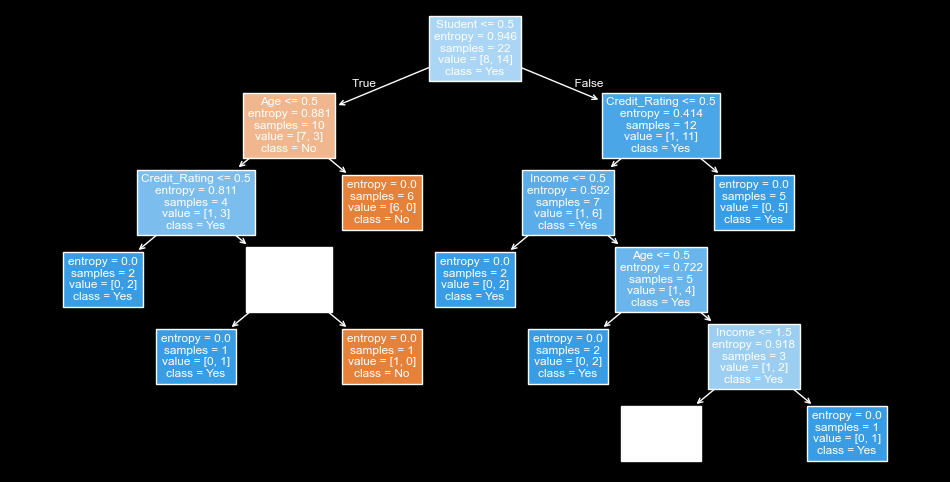

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

## Q9: Predict and Evaluate

In [42]:
y_pred = dt.predict(X_test)
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
display(results)
print('\nAccuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

,Actual,Predicted,Status
0,1,0,Wrong
1,1,1,Correct
2,1,1,Correct
3,0,0,Correct
4,1,1,Correct
5,1,0,Wrong



Accuracy: 0.6666666666666666

Confusion Matrix:
 [[1 0]
 [2 3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.60      0.75         5

    accuracy                           0.67         6
   macro avg       0.67      0.80      0.62         6
weighted avg       0.89      0.67      0.71         6



## Q10: Classify a New Sample & Answer Queries

In [43]:
# Example: Outlook=Sunny, Temperature=Mild, Humidity=High, Wind=Weak
sample = pd.DataFrame({
    'Age':['Young'],
    'Income':['High'],
    'Student':['No'],
    'Credit_Rating':['Fair'],
})

# encode sample using same encoders
encoded_sample = sample.copy()
for col in encoded_sample.columns:
    encoded_sample[col] = encoders[col].transform(encoded_sample[col])

prediction = dt.predict(encoded_sample)
label = encoders['Loan_Approved'].inverse_transform(prediction)
print('Prediction for sample:', label[0])

Prediction for sample: No


---
### ✔ End of Assignment-6
In this assignment, we implemented a Decision Tree Classifier to analyze and predict outcomes based on structured data. The model effectively learned decision rules by splitting the dataset on different features such as age, income, student status, and credit rating. This hierarchical structure made the model highly interpretable, allowing us to clearly understand how predictions were made.

The results demonstrated that decision trees are powerful for handling categorical data and capturing non-linear relationships without requiring complex preprocessing. However, we also observed that decision trees can be prone to overfitting if not properly controlled through techniques like pruning or limiting tree depth.

Overall, this assignment highlights the usefulness of decision trees as both a predictive and explanatory tool in machine learning, especially for classification problems where interpretability is important.